# 步骤 07 · 分类器 —— 以及一个关于"准确率"的教训

**这一节的产出：图 7a（混淆矩阵）+ 图 7b（四种划分方式下的准确率）+ 图 7c（为什么会失败）。**

## 前六步已经能诊断了，为什么还要分类器

步骤 06 的方法要求你**知道轴承的几何参数和转速**，然后手工检查得分。分类器想做的是：喂进一段振动，直接吐出一个标签。

这是工业界真实的需求 —— 一条产线上几百个轴承，没人有空一个个看包络谱。

**但这一节真正要教的不是怎么训练模型**（那是 `sklearn` 三行代码的事），而是：

> **怎么判断一个准确率数字是不是真的。**

这件事比模型本身重要得多，而且是绝大多数人做错的地方。

## 数据

40 条记录：健康 + 三种故障位置 × 三种坑大小，每种都有 4 个负载。每条切成 2048 点一段，共 2331 段。

四类标签：`healthy` / `outer` / `inner` / `ball`。

---
## 1. 特征：两个家族，故意分开

| 家族 | 特征 | 来自 |
|---|---|---|
| **时域 3 个** | RMS、峭度、峰值因子 | 步骤 02 |
| **包络 6 个** | BPFO / BPFI / BSF 及其二倍频处的**峰背比** | 步骤 05–06 |

分开是为了能问一个问题：**这两家各值多少钱？**

步骤 02 论证过时域统计量**原理上**不可能分辨故障类型（打乱样本顺序它们不变，而故障类型只活在顺序里）。这一节会检验那个论断在真实的分类任务里成不成立 —— **结果会让你意外，然后让你想清楚。**

### 为什么包络特征用峰背比而不是能量占比

我两种都试过：

| 特征形式 | 跨未见尺寸的准确率 |
|---|---|
| 能量占比（该频率能量 / 本段总能量） | 42.1% |
| **峰背比**（该频率峰高 / 旁边几 Hz 的背景） | **50.7%** |

区别在于**拿什么当分母**。能量占比的分母是这一段自己的总能量，而那主要由"机器此刻抖得多厉害"决定 —— 也就是负载和坑的大小。**那正是分类器不该依赖的东西**（依赖了，换个坑大小就废）。

峰背比的分母是**旁边几赫兹的背景**，所以整体振动强度被约掉了。

> 这是个通用原则：**特征的归一化方式决定了它对什么敏感。** 选分母时要问：我想让这个特征随什么变、不随什么变？

---
## 2. 准备与建表

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import (StratifiedKFold, GroupKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import accuracy_score, confusion_matrix

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import dataset
import features as ft

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

records = dataset.catalogue()
print(f"{len(records)} 条记录，切成 {ft.SEGMENT} 点一段，"
      f"包络频带 {ft.BAND[0]}-{ft.BAND[1]} Hz\n")

X, meta, cols = ft.build_table(records, DATA, verbose=False)
y = np.array([m["label"] for m in meta])
groups = np.array([m["file"] for m in meta])     # 哪个文件
load = np.array([m["load"] for m in meta])       # 哪个负载
size = np.array([m["size"] for m in meta])       # 坑多大

print(f"特征表 {X.shape}")
print(f"列: {cols}\n")
for c, n in zip(*np.unique(y, return_counts=True)):
    print(f"  {c:<9}{n:>6} 段")

40 条记录，切成 2048 点一段，包络频带 1000-3000 Hz

特征表 (2331, 9)
列: ['rms', 'kurtosis', 'crest', 'BPFO_x1', 'BPFO_x2', 'BPFI_x1', 'BPFI_x2', 'BSF_x1', 'BSF_x2']

  ball        708 段
  healthy     206 段
  inner       709 段
  outer       708 段


### 一个已经被挡掉的坑

`features.segment()` 切段时**不重叠**。

如果用重叠窗口（比如每次滑动 1024 点），相邻两段会**共享一半样本**。那么把其中一段放训练集、另一段放测试集，测试集里就有训练集见过的数据 —— **泄漏**。

很多教程为了"增加样本量"用重叠窗口，然后报告一个虚高的准确率。

> 另外注意 `build_table` 是**按记录逐条**算故障频率的。四个负载转速不同（1797/1772/1750/1730 rpm），BPFO 从 107.4 Hz 变到 103.1 Hz。一段 2048 点的频率分辨率是 5.9 Hz，**这个偏移和分辨率同量级** —— 用固定频率会让特征在 0 hp 和 3 hp 上系统性偏掉。

---
## 3. 四种划分方式

这是全节的核心。**同一个模型、同一份数据，换个划分方式，准确率可以从 97% 掉到 33%。**

| | 怎么分 | 在问什么问题 |
|---|---|---|
| **A** 随机打乱 | 2331 段随便洗牌，5 折 | 几乎什么都没问 |
| **B** 按文件分组 | 整个文件要么全训练、要么全测试 | 换一条新录音还认得吗 |
| **C** 留一负载 | 3 个负载训练，第 4 个测试 | 换个工况还认得吗 |
| **D** 留一故障尺寸 | 2 种坑大小训练，第 3 种测试 | **换个没见过的故障还认得吗** |

越往下越难，也越接近现实 —— 现实中你遇到的故障，**不会和训练集里的一模一样**。

In [2]:
def model():
    # 标准化 + RBF 核 SVM。标准化是必须的：RMS 是 0.06 量级，
    # 峰背比是几十量级，不缩放的话距离几乎只由后者决定。
    return make_pipeline(StandardScaler(), SVC(C=10, gamma="scale"))


TIME = [0, 1, 2]
ENV = [3, 4, 5, 6, 7, 8]
SETS = [("时域 3 个", TIME), ("包络 6 个", ENV), ("全部 9 个", TIME + ENV)]

# 图里一律用英文：matplotlib 默认字体没有中文字形，中文会画成方框。
# 报告本来也是英文的，所以图上不出现中文反而省事。
EN = {"时域 3 个": "time-domain (3)",
      "包络 6 个": "envelope (6)",
      "全部 9 个": "all (9)"}


def leave_one_out(idx, key_array, skip=()):
    accs = []
    for value in np.unique(key_array):
        if value in skip:
            continue
        is_test = key_array == value
        m = model().fit(X[~is_test][:, idx], y[~is_test])
        accs.append(accuracy_score(y[is_test], m.predict(X[is_test][:, idx])))
    return accs


results = {}
print(f"{'划分方式':<24}" + "".join(f"{n:>13}" for n, _ in SETS))
print("-" * 64)

for label, fn in [
    ("A 随机打乱 5 折",
     lambda idx: cross_val_score(model(), X[:, idx], y,
                                 cv=StratifiedKFold(5, shuffle=True,
                                                    random_state=0)).mean()),
    ("B 按文件分组 5 折",
     lambda idx: cross_val_score(model(), X[:, idx], y,
                                 cv=GroupKFold(5), groups=groups).mean()),
    ("C 留一负载",
     lambda idx: np.mean(leave_one_out(idx, load))),
    ("D 留一故障尺寸",
     lambda idx: np.mean(leave_one_out(idx, size, skip=(0.0,)))),
]:
    vals = [fn(idx) for _, idx in SETS]
    results[label] = vals
    print(f"{label:<24}" + "".join(f"{v:>12.1%} " for v in vals))

print("\nD 的测试集只含三类故障（健康记录没有'坑的大小'，始终在训练集里）")
print("三类问题的随机猜测基线 = 33.3%")

划分方式                           时域 3 个       包络 6 个       全部 9 个
----------------------------------------------------------------
A 随机打乱 5 折                     97.0%        77.9%        95.9% 
B 按文件分组 5 折                    96.3%        76.1%        93.5% 
C 留一负载                         96.5%        75.6%        93.9% 
D 留一故障尺寸                       33.1%        50.7%        48.3% 

D 的测试集只含三类故障（健康记录没有'坑的大小'，始终在训练集里）
三类问题的随机猜测基线 = 33.3%


---
## 4. 读这张表 —— 三个结论，一个比一个重要

### 结论一：A 和 B 差别很小，这和常见的警告不一样

| | 时域 3 个 | 全部 9 个 |
|---|---|---|
| A 随机打乱 | 97.0% | 95.9% |
| B 按文件分组 | 96.3% | 93.5% |

到处都能看到"随机划分会泄漏，准确率虚高到 99%"的说法。**在这份数据上，按文件分组只掉了 0.7–2.4 个百分点。**

为什么？因为**真正的泄漏不在段之间，在工况之间**。

把"外圈 0.007″ 1 hp"整条拿去做测试集，训练集里**还剩外圈 0.007″ 的 0 hp、2 hp、3 hp 三条** —— 几乎一样的东西。模型根本不需要理解什么，认出"这看起来像我见过的那几条"就够了。

> **这是这一节最实用的一条**：分组划分要按**你希望模型泛化的那个维度**来分，不是按文件。按文件分组听起来严谨，实际上什么也没挡住。

### 结论二：C（留一负载）也几乎没掉，因为换负载太容易了

96.5%。四个负载的转速只差 4%，振动特性高度相似。**这个测试看起来严格，其实很宽松。**

路线图里把"跨负载泛化"列为一个未做的局限。我们做了 —— **然后发现它根本不难。** 如实写进报告比留着当"未来工作"诚实。

### 结论三：D（留一故障尺寸）—— 全线崩溃

| | D 的准确率 |
|---|---|
| 时域 3 个 | **33.1%** |
| 包络 6 个 | 50.7% |
| 全部 9 个 | 48.3% |

**三类问题的随机猜测是 33.3%。时域特征的 33.1% 就是纯随机 —— 一点信息都没有。**

那个 96.3% 呢？**它是查表。**

---
## 5. 为什么时域特征会从 96% 掉到随机

这直接印证了步骤 02 和步骤 06 的论断，只是这次是量化的。

回忆步骤 02 之后测的那张表（十条记录的峭度）：

```
22.08  Inner 0.014"      7.59  Outer 0.007"
21.97  Outer 0.021"      5.54  Inner 0.007"
 9.41  Ball  0.021"      2.98  HEALTHY
 8.84  Ball  0.014"      2.96  Ball  0.007"
 7.67  Inner 0.021"      2.94  Outer 0.014"
```

**同一类故障的峭度横跨整个范围，不同类之间完全交织。**

那 SVM 是怎么拿到 96% 的？因为在 (RMS, 峭度, 峰值因子) 这个三维空间里，**40 个文件形成 40 个很紧的簇**（步骤 02 测过：同一文件内各段的标准差只有 0.001~0.3）。SVM 学的是"哪个簇属于哪一类" —— 一张查找表。

只要测试样本落进一个见过的簇附近，它就答对。**换一个没见过的坑大小，簇跑到了新位置，查找表失效，准确率回到随机。**

> 这正是步骤 06 里那句话的机器学习版本：
>
> **"能在这份数据上分开"是拟合，"能说出为什么"才是诊断。**

### 包络特征好一些，但也只是好一些

50.7% vs 随机的 33.3%。它确实带着物理信息 —— 峰背比量的是"理论预测的那个频率上有没有周期性冲击"，这个量**不依赖坑有多大**。

但它也没能守住。原因下一节的图会说清楚。

In [3]:
# 每个被留出的尺寸单独看
print(f"{'特征':<12}" + "".join(f"{f'测 {s}in':>12}" for s in (0.007, 0.014, 0.021)))
print("-" * 50)
per_size = {}
for n, idx in SETS:
    accs = []
    for te in (0.007, 0.014, 0.021):
        is_test = size == te
        m = model().fit(X[~is_test][:, idx], y[~is_test])
        accs.append(accuracy_score(y[is_test], m.predict(X[is_test][:, idx])))
    per_size[n] = accs
    print(f"{n:<12}" + "".join(f"{a:>11.1%} " for a in accs))
print("\n0.014in 那一列对所有特征都最差 —— 那一组记录本身就异常")
print("（步骤 02：外圈 0.014in 的峭度 2.94，比健康记录的 2.98 还低）")

特征             测 0.007in   测 0.014in   测 0.021in
--------------------------------------------------
时域 3 个            33.3%       29.8%       36.3% 
包络 6 个            58.4%       31.6%       62.0% 
全部 9 个            65.4%       30.8%       48.7% 

0.014in 那一列对所有特征都最差 —— 那一组记录本身就异常
（步骤 02：外圈 0.014in 的峭度 2.94，比健康记录的 2.98 还低）


---
## 6. 图 7a：混淆矩阵

准确率是一个数，**混淆矩阵告诉你错在哪** —— 而"错在哪"往往比"错多少"有用。

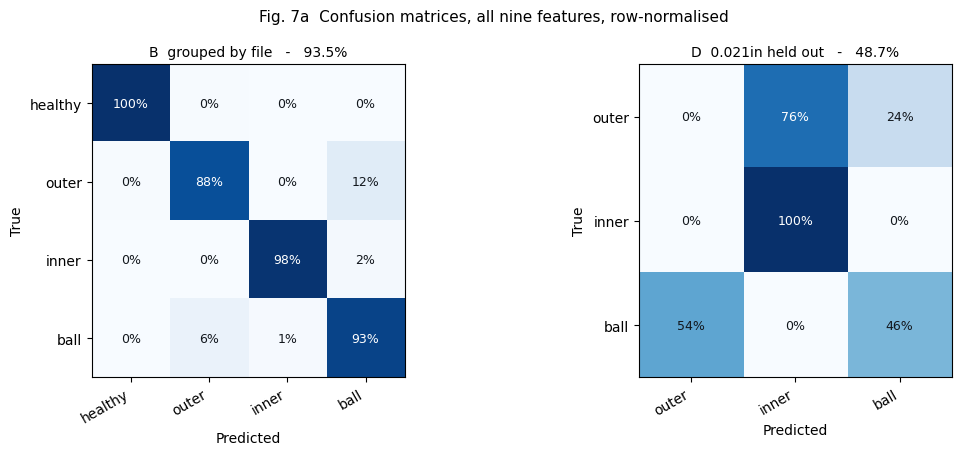

In [4]:
LABELS4 = ["healthy", "outer", "inner", "ball"]
LABELS3 = ["outer", "inner", "ball"]


def draw_cm(ax, cm, labels, title):
    norm = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontsize=10)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{norm[i, j]:.0%}", ha="center", va="center",
                    fontsize=9,
                    color="white" if norm[i, j] > 0.55 else "#12171D")
    return im


fig7a, (axB, axD) = plt.subplots(1, 2, figsize=(11.5, 4.6))

yp_B = cross_val_predict(model(), X, y, cv=GroupKFold(5), groups=groups)
cmB = confusion_matrix(y, yp_B, labels=LABELS4)
draw_cm(axB, cmB, LABELS4,
        f"B  grouped by file   -   {accuracy_score(y, yp_B):.1%}")

is_test = size == 0.021
m = model().fit(X[~is_test], y[~is_test])
yp_D = m.predict(X[is_test])
cmD = confusion_matrix(y[is_test], yp_D, labels=LABELS3)
draw_cm(axD, cmD, LABELS3,
        f'D  0.021in held out   -   {accuracy_score(y[is_test], yp_D):.1%}')

fig7a.suptitle("Fig. 7a  Confusion matrices, all nine features, row-normalised",
               fontsize=11)
fig7a.tight_layout()
plt.show()

### 读图 7a

**左边（按文件分组，93.5%）**：对角线很亮。主要的混淆是**外圈 ↔ 滚珠**（外圈有 12% 被判成滚珠，滚珠有 7% 被判成外圈）。这和前面所有步骤一致 —— 滚珠故障从头到尾都是最难的。

**右边（留出 0.021″，48.7%）**：

| 真值 | 召回 |
|---|---|
| outer | **0%** |
| inner | 100% |
| ball | 46% |

**外圈 0.021″ 一条都没认出来，全部被判成内圈或滚珠。**

准确率 48.7% 看起来"还行"，但它是由"内圈 100% 对"撑起来的假象。**一个把整整一类全判错的模型，不管总准确率多少，都不能用。**

> **只看准确率会漏掉这种失败。** 混淆矩阵是必须画的，尤其当类别不平衡或者你关心某一类的时候。

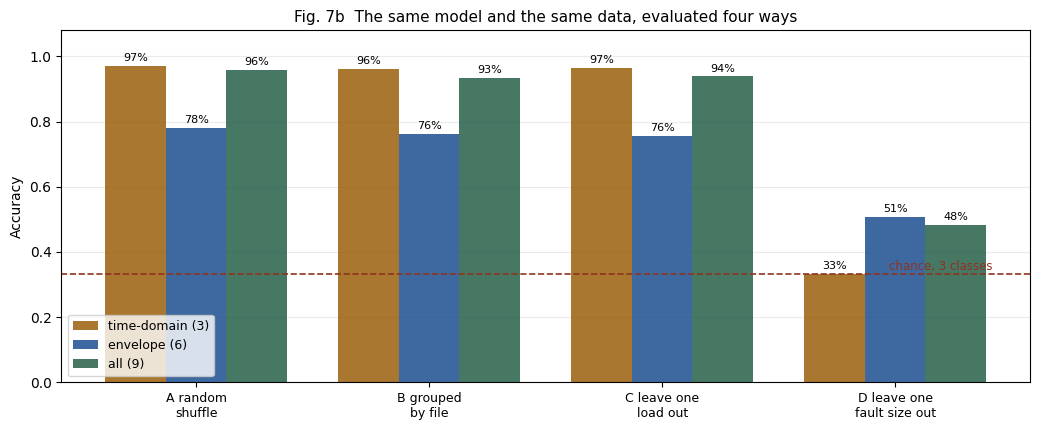

In [5]:
# 图 7b：四种划分方式 x 三组特征
fig7b, ax = plt.subplots(figsize=(10.5, 4.4))

splits = list(results)
w = 0.26
colors = ["#9A5F0A", "#1B4F8F", "#256049"]

for j, ((name, _), c) in enumerate(zip(SETS, colors)):
    vals = [results[s][j] for s in splits]
    bars = ax.bar(np.arange(len(splits)) + (j - 1) * w, vals, width=w,
                  color=c, alpha=0.85, label=EN[name])
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.0%}",
                ha="center", fontsize=8)

ax.axhline(1 / 3, color="#8E3320", linestyle="--", linewidth=1.2)
ax.text(3.42, 0.345, "chance, 3 classes", fontsize=8.5, color="#8E3320", ha="right")
ax.set_xticks(range(len(splits)))
ax.set_xticklabels(["A random\nshuffle", "B grouped\nby file",
                    "C leave one\nload out", "D leave one\nfault size out"],
                   fontsize=9)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.08)
ax.legend(fontsize=9, loc="lower left")
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
ax.set_title("Fig. 7b  The same model and the same data, evaluated four ways",
             fontsize=11)
fig7b.tight_layout()
plt.show()

**这张图是整节的结论。** 同一个模型、同一份数据、同一组特征 —— 准确率从 97% 到 33%，**差别全在你怎么划分训练集和测试集。**

如果一篇报告只写"准确率 96%"而不说划分方式，这个数字**没有任何信息量**。

---
## 7. 图 7c：为什么会失败，画出来看

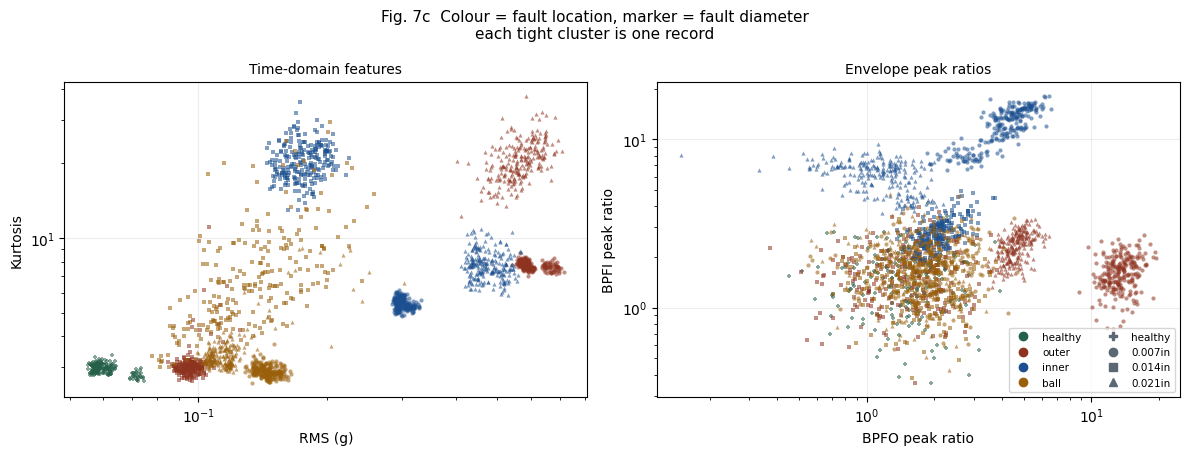

In [6]:
fig7c, axes = plt.subplots(1, 2, figsize=(12, 4.6))

CLS = {"healthy": "#256049", "outer": "#8E3320",
       "inner": "#1B4F8F", "ball": "#9A5F0A"}
MARK = {0.000: "P", 0.007: "o", 0.014: "s", 0.021: "^"}

for ax, (i, j), names in [
        (axes[0], (0, 1), ("RMS (g)", "Kurtosis")),
        (axes[1], (3, 5), ("BPFO peak ratio", "BPFI peak ratio"))]:
    for cls in CLS:
        for sz in sorted(MARK):
            m = (y == cls) & (size == sz)
            if not m.any():
                continue
            ax.scatter(X[m, i], X[m, j], s=9, alpha=0.55, color=CLS[cls],
                       marker=MARK[sz], linewidths=0)
    ax.set_xlabel(names[0])
    ax.set_ylabel(names[1])
    ax.grid(alpha=0.22)
    ax.set_axisbelow(True)

axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Time-domain features", fontsize=10)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Envelope peak ratios", fontsize=10)

handles = [plt.Line2D([], [], marker="o", linestyle="", color=c, label=k)
           for k, c in CLS.items()]
handles += [plt.Line2D([], [], marker=mk, linestyle="", color="#5B6773",
                       label=f'{s:.3f}in' if s else "healthy")
            for s, mk in sorted(MARK.items())]
axes[1].legend(handles=handles, fontsize=7.5, ncol=2, loc="lower right")

fig7c.suptitle("Fig. 7c  Colour = fault location, marker = fault diameter\n"
               "each tight cluster is one record", fontsize=11)
fig7c.tight_layout()
plt.show()

### 读图 7c —— 一眼看懂为什么

**左边（时域特征）**：每一个小簇就是一条记录。同色的簇（同一种故障）**散落在各处**，位置主要由标记形状（坑的大小）决定，不由颜色决定。

**把某个形状的所有簇拿走当测试集，剩下的簇给不出任何关于它们的信息。** 这就是 33% 的来源。

**右边（包络峰背比）**：同色的点**聚拢得多**。蓝色（内圈）在 BPFI 方向拉开，红色（外圈）在 BPFO 方向拉开 —— **因为这两个轴本来就是按物理定义的**，不是从数据里学出来的。

这就是包络特征从 33% 提到 50% 的原因。**它没能完全成功，但它失败得比时域特征体面得多，而且理由清楚。**

---
## 8. 和步骤 06 那个不学习的方法比一比

这是这一节最该被写进报告的一段。

**步骤 06 的方法不训练、不学习。** 它只做一件事：从轴承几何算出三个候选频率，在包络谱上看哪个有成列的谐波。

九条故障记录（三种位置 × 三种坑大小）上的表现：

In [7]:
import envelope as ev

THRESHOLD = 11.06         # 步骤 06：健康记录在相同搜索下的最高分
GRID = ev.band_grid()
KEY = {"outer": "BPFO", "inner": "BPFI", "ball": "BSF"}

faults = [r for r in records if not r.is_healthy and r.load == 1]

# 和步骤 06 用同样的截断长度，否则数字对不上 —— 见下一节的说明
N06 = 120976

print("步骤 06 的物理规则（完全不训练），1 hp 的九条记录\n")
print(f"{'记录':<20}{'comb':>9}{'/阈值':>8}{'判定':>7}{'真值':>7}   结果")
print("-" * 62)
n_ok = n_declined = n_false = 0
for r in faults:
    sig = r.load_signal(DATA)
    band, score, which, _ = ev.select_band(sig.x[:N06], sig.fault_freqs(), GRID)
    truth = KEY[r.location]
    if score <= THRESHOLD:
        verdict = "拒答"; n_declined += 1
    elif which == truth:
        verdict = "正确"; n_ok += 1
    else:
        verdict = "** 误诊 **"; n_false += 1
    print(f"{r.label:<20}{score:>9.2f}{score/THRESHOLD:>7.1f}x"
          f"{which:>7}{truth:>7}   {verdict}")

print(f"\n  正确 {n_ok}   拒答 {n_declined}   误诊 {n_false}")
print("\n  注意：这个方法从来没有'见过'任何一条记录。")
print("  它对 0.021in 的表现和对 0.007in 一样 —— 因为它不靠见过。")

步骤 06 的物理规则（完全不训练），1 hp 的九条记录

记录                       comb     /阈值     判定     真值   结果
--------------------------------------------------------------
inner 0.007" 1hp       226.92   20.5x   BPFI   BPFI   正确
inner 0.014" 1hp        36.42    3.3x   BPFI   BPFI   正确
inner 0.021" 1hp        69.37    6.3x   BPFI   BPFI   正确
ball 0.007" 1hp          9.66    0.9x   BPFO    BSF   拒答
ball 0.014" 1hp         10.37    0.9x   BPFO    BSF   拒答
ball 0.021" 1hp         14.52    1.3x   BPFI    BSF   ** 误诊 **
outer 0.007" 1hp       431.90   39.1x   BPFO   BPFO   正确
outer 0.014" 1hp        12.86    1.2x   BPFO   BPFO   正确
outer 0.021" 1hp        85.10    7.7x   BPFO   BPFO   正确

  正确 6   拒答 2   误诊 1

  注意：这个方法从来没有'见过'任何一条记录。
  它对 0.021in 的表现和对 0.007in 一样 —— 因为它不靠见过。


### 先说一件我在写这一节时撞到的事

上面那格里有一行 `N06 = 120976`，把记录截到和步骤 06 相同的长度。

**不截的话，滚珠 0.014″ 的判定会从"拒答"翻成"误诊"** —— 它的 comb 得分从 10.37 变成 11.28，而阈值是 11.06。多用了几千个样本，结论就反了。

这不是 bug，**这是步骤 06 那个"灰色地带"结论的又一个证据**：卡在 1.0 倍阈值上的记录，结论不稳定到连"用多长的数据"都能改变它。

> 顺带一个实用教训：**跨章节引用数字时，处理参数必须完全一致，否则读者会以为你算错了。** 我在这里显式写死 `N06`，并在注释里说明原因，而不是让它悄悄地不一样。

### 对比

| | 见过 0.021″ 吗 | 外圈 0.021″ 的结果 |
|---|---|---|
| 分类器（留出 0.021″） | 没见过 | **召回 0%** |
| 步骤 06 的物理规则 | 从不需要见过 | **正确** |

**差别的根源不在模型好坏，在于两者在做不同的事。**

- 分类器学的是"**这种振动长什么样 → 是哪类故障**"。这个映射随坑的大小改变，所以见过的形态之外它就不会了。
- 物理规则测的是"**冲击的节奏是不是 105.9 Hz**"。这个频率由轴承几何和转速决定，**和坑多大无关**。

> 这不是说机器学习没用。**是说：当你手里有一个从物理推出来的量时，去测它，比去学一个从数据到标签的映射更可靠。**
>
> 机器学习的价值在于那些你**写不出物理模型**的问题。轴承故障频率恰好是能写出来的 —— 那就别浪费这个优势。

---
## 9. 这一节在报告里怎么写

**不要写"分类器准确率 96%"。** 那句话在这份数据上是误导的。

按这个结构写：

| 段落 | 内容 |
|---|---|
| 特征 | 两个家族，为什么包络用峰背比而不是能量占比 |
| 评估设计 | 四种划分，各在问什么问题 |
| 结果 | **图 7b** —— 97% / 93.5% / 93.9% / 48.3% |
| 关键发现 | 按文件分组几乎没挡住泄漏；真正的泄漏在**工况之间** |
| 失败分析 | **图 7a 右** —— 外圈 0.021″ 召回 0%，准确率 48.7% 是假象 |
| 解释 | **图 7c 左** —— 时域特征的簇按坑大小排布，不按故障类型 |
| 对照 | 步骤 06 的物理规则在同样的未见尺寸上仍然正确 |
| 局限 | 单一实验台、单一轴承型号、坑是人工加工的 |

**三句核心：**

> 1. **"同一模型同一数据，准确率随划分方式从 97.0% 变到 33.1%；因此任何不声明划分方式的准确率都不可解释。"**
>
> 2. **"按文件分组划分只让准确率下降 2.4 个百分点，因为同一工况的其他记录仍在训练集中。真正的泛化差距出现在留出故障尺寸时（48.3%），此时时域特征退化到随机水平（33.1%，基线 33.3%）。"**
>
> 3. **"在同样未见的故障尺寸上，步骤 06 基于轴承几何的判据仍给出正确诊断。学习一个从波形到标签的映射不能外推到未见故障，测量一个由几何预测的频率可以。"**

第 2 句里那个"33.1% vs 基线 33.3%"是最有力的 —— **它不是"效果不好"，是"完全没有信息"。** 一个精确到这种程度的负面结果，比任何正面结果都难以反驳。

---
## 10. 保存

In [8]:
FIGURES.mkdir(exist_ok=True)
for fig, name in [(fig7a, "fig07a_confusion.png"),
                  (fig7b, "fig07b_accuracy_by_split.png"),
                  (fig7c, "fig07c_feature_space.png")]:
    p = FIGURES / name
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print("已保存:", p)

p = FIGURES / "table06_classifier.txt"
with open(p, "w", encoding="utf-8") as fh:
    fh.write("Four-class segment classification, RBF SVM on standardised features\n")
    fh.write(f"{len(records)} records, {ft.SEGMENT}-sample segments, "
             f"{X.shape[0]} rows, envelope band {ft.BAND[0]}-{ft.BAND[1]} Hz\n\n")
    fh.write(f"{'split':<28}" + "".join(f"{EN[n]:>19}" for n, _ in SETS) + "\n")
    fh.write("-" * 85 + "\n")
    names = {"A 随机打乱 5 折": "A random shuffle",
             "B 按文件分组 5 折": "B grouped by file",
             "C 留一负载": "C leave one load out",
             "D 留一故障尺寸": "D leave one fault size out"}
    for k, vals in results.items():
        fh.write(f"{names[k]:<28}" + "".join(f"{v:>19.1%}" for v in vals) + "\n")
    fh.write("\nD tests three fault classes only; chance is 33.3%.\n")
    fh.write("Time-domain features reach 33.1% there - no information at all.\n")
print("已保存:", p)

已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\fig07a_confusion.png
已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\fig07b_accuracy_by_split.png
已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\fig07c_feature_space.png
已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\table06_classifier.txt


---
## 11. 自己动手

In [9]:
# 练习 1：段长的影响
# ------------------------------------------------
# 段越长 -> 频率分辨率越好，但样本数越少
for seg_len in (512, 1024, 2048, 4096):
    Xs, ms, _ = ft.build_table(records, DATA, length=seg_len, verbose=False)
    ys = np.array([m["label"] for m in ms])
    gs = np.array([m["file"] for m in ms])
    zs = np.array([m["size"] for m in ms])
    b = cross_val_score(model(), Xs, ys, cv=GroupKFold(5), groups=gs).mean()
    d = []
    for te in (0.007, 0.014, 0.021):
        t = zs == te
        mm = model().fit(Xs[~t], ys[~t])
        d.append(accuracy_score(ys[t], mm.predict(Xs[t])))
    print(f"  段长 {seg_len:>5}  ({seg_len/12000*1000:5.1f} ms, "
          f"分辨率 {12000/seg_len:4.1f} Hz)  "
          f"B={b:5.1%}   D={np.mean(d):5.1%}   样本 {len(ys)}")

print("\nB 和 D 随段长怎么变？哪个更稳定？为什么？")

  段长   512  ( 42.7 ms, 分辨率 23.4 Hz)  B=87.7%   D=54.7%   样本 9386
  段长  1024  ( 85.3 ms, 分辨率 11.7 Hz)  B=91.5%   D=60.6%   样本 4683
  段长  2048  (170.7 ms, 分辨率  5.9 Hz)  B=93.5%   D=48.3%   样本 2331
  段长  4096  (341.3 ms, 分辨率  2.9 Hz)  B=94.2%   D=47.3%   样本 1146

B 和 D 随段长怎么变？哪个更稳定？为什么？


In [10]:
# 练习 2：换个模型，结论会变吗
# ------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

MODELS = {
    "SVM-RBF":  lambda: make_pipeline(StandardScaler(), SVC(C=10, gamma="scale")),
    "LogReg":   lambda: make_pipeline(StandardScaler(),
                                      LogisticRegression(max_iter=3000)),
    "随机森林": lambda: RandomForestClassifier(n_estimators=200, random_state=0),
}

print(f"{'模型':<12}{'B 按文件':>12}{'D 留一尺寸':>14}")
print("-" * 40)
for name, mk in MODELS.items():
    b = cross_val_score(mk(), X, y, cv=GroupKFold(5), groups=groups).mean()
    d = []
    for te in (0.007, 0.014, 0.021):
        t = size == te
        mm = mk().fit(X[~t], y[~t])
        d.append(accuracy_score(y[t], mm.predict(X[t])))
    print(f"{name:<12}{b:>11.1%} {np.mean(d):>13.1%}")

print("\n三个模型的 B 都很高、D 都很低 —— 说明问题不在模型，在数据和任务本身。")
print("换模型救不了泛化，这是个很重要的判断：什么时候该换模型，什么时候该换思路。")

模型                 B 按文件        D 留一尺寸
----------------------------------------
SVM-RBF           93.5%         48.3%
LogReg            83.6%         41.1%
随机森林              96.8%         56.6%

三个模型的 B 都很高、D 都很低 —— 说明问题不在模型，在数据和任务本身。
换模型救不了泛化，这是个很重要的判断：什么时候该换模型，什么时候该换思路。


In [11]:
# 练习 3：只用一个特征能走多远
# ------------------------------------------------
print(f"{'单个特征':<14}{'B 按文件':>11}{'D 留一尺寸':>13}")
print("-" * 40)
for i, name in enumerate(cols):
    b = cross_val_score(model(), X[:, [i]], y, cv=GroupKFold(5),
                        groups=groups).mean()
    d = []
    for te in (0.007, 0.014, 0.021):
        t = size == te
        mm = model().fit(X[~t][:, [i]], y[~t])
        d.append(accuracy_score(y[t], mm.predict(X[t][:, [i]])))
    print(f"{name:<14}{b:>10.1%} {np.mean(d):>12.1%}")

print("\n哪个单特征的 D 最高？它属于哪个家族？这说明了什么？")

单个特征                B 按文件       D 留一尺寸
----------------------------------------
rms                84.9%        49.2%
kurtosis           48.0%        14.3%
crest              40.1%        15.4%
BPFO_x1            48.4%        39.2%
BPFO_x2            44.9%        35.1%
BPFI_x1            55.8%        42.7%
BPFI_x2            56.2%        42.1%
BSF_x1             33.1%        19.4%
BSF_x2             38.6%        40.2%

哪个单特征的 D 最高？它属于哪个家族？这说明了什么？


---
## 小结

| 做了 | 结论 |
|---|---|
| 40 条记录 → 2331 段 → 9 个特征 | 时域 3 + 包络峰背比 6 |
| A 随机打乱 | 97.0% |
| B 按文件分组 | 93.5% —— **只掉了 2.4 点，因为真正的泄漏在工况之间** |
| C 留一负载 | 93.9% —— 换负载其实很容易 |
| D 留一故障尺寸 | **48.3%**，时域特征 **33.1% = 随机** |
| 混淆矩阵（图 7a） | 留出 0.021″ 时外圈**召回 0%**，48.7% 是假象 |
| 特征空间（图 7c） | 时域的簇按**坑大小**排布，不按故障类型 |
| 对照步骤 06 | 物理规则在同样未见的尺寸上**仍然正确** |

**还有一件练习 1 会挖出来的事，值得提前说**：段长 1024 点在 D 上得到 **60.6%**，比我默认用的 2048 点（48.3%）好得多，尽管它在 B 上更差（91.5% vs 93.5%）。

**"最优段长"取决于你优化哪个指标。** 如果你只看 B，会选 4096（94.2%）；如果你关心泛化，该选 1024。我用 2048 是沿用路线图的建议，**它两头都不是最好的** —— 这一条也如实写进报告。

**这一节真正的产出不是一个分类器，是一个关于怎么读准确率的判断力。**

> 同一个模型、同一份数据，97% 和 33% 都是"真实"的数字。**决定哪个有意义的，是你划分数据的方式，而那取决于你想让模型在什么情况下工作。**

---

## 整个项目到这里结束了

| 步骤 | 结论 |
|---|---|
| 01 波形 | 外圈能用眼睛数出 21 簇 ≈ BPFO |
| 02 统计量 | 能检测，不能诊断，**且原理上不可能** |
| 03 直接 FFT | 有峰但健康记录也有 —— **会误判** |
| 04 时频图 | 看见节奏，粗糙包络已能诊断 |
| 05 包络谱 | 外圈 635、内圈 237，滚珠失败 |
| 06 选共振带 | 盲选 + 健康标定阈值；**九条里一次误诊，圈进"存疑"档** |
| 07 分类器 | **准确率取决于划分方式；物理规则在未见故障上更可靠** |

**下一步是写报告。** 现在你有 13 张图、6 张表，以及一条完整的、每一步都有证据的论证链 —— 包括三次失败（滚珠诊断、一次误诊、分类器不泛化），而那三次是这份材料里最有说服力的部分。